# FULLY AUTOMATED TTA: BiomedCLIP + Memory Bank

**100% Automated - Just Run and Wait**

Uses shell commands (`!python`) for BiomedCLIP - fully automated, no manual intervention.

**Pipeline:**
1. Literature weights (T1CE=60%, FLAIR=30%) as initialization
2. Memory bank adaptation per patient
3. BiomedCLIP saliency via shell commands (automated)
4. SAM segmentation

**Expected time:** ~30-40 minutes for 20 patients

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import cv2
import torch
import SimpleITK as sitk
from pathlib import Path
from tqdm import tqdm
import json
import shutil
import os
from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Change to working directory
os.chdir('C:/Users/arnav/Desktop/MedBIND3D/MedBIND3D/medclipsam/MedCLIP-SAMv2')
print(f"Working directory: {os.getcwd()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Working directory: C:\Users\arnav\Desktop\MedBIND3D\MedBIND3D\medclipsam\MedCLIP-SAMv2
Device: cuda


## 2. Load Dataset & Utilities

In [2]:
class BraTSDataset:
    def __init__(self, data_root):
        self.data_root = Path(data_root)
        self.patient_dirs = sorted([d for d in self.data_root.iterdir() if d.is_dir()])
        print(f"Found {len(self.patient_dirs)} patients")
    
    def load_patient(self, idx):
        patient_dir = self.patient_dirs[idx]
        patient_id = patient_dir.name
        modalities = {}
        for mod in ['t1', 't1ce', 't2', 'flair']:
            file = list(patient_dir.glob(f'*{mod}.nii*'))[0]
            img = sitk.ReadImage(str(file))
            modalities[mod.upper()] = sitk.GetArrayFromImage(img).transpose(1, 2, 0)
        seg_file = list(patient_dir.glob('*seg.nii*'))[0]
        seg_img = sitk.ReadImage(str(seg_file))
        seg = sitk.GetArrayFromImage(seg_img).transpose(1, 2, 0)
        return modalities, seg, patient_id

def compute_snr(modality_slice, tumor_mask):
    tumor_pixels = modality_slice[tumor_mask > 0]
    background_pixels = modality_slice[tumor_mask == 0]
    if len(tumor_pixels) == 0 or len(background_pixels) == 0:
        return 0.0
    tumor_mean = tumor_pixels.mean()
    background_mean = background_pixels.mean()
    background_std = background_pixels.std()
    if background_std < 1e-8:
        return 0.0
    return float((tumor_mean - background_mean) / background_std)

def compute_cnr(modality_slice, tumor_mask):
    tumor_pixels = modality_slice[tumor_mask > 0]
    background_pixels = modality_slice[tumor_mask == 0]
    if len(tumor_pixels) == 0 or len(background_pixels) == 0:
        return 0.0
    tumor_mean = tumor_pixels.mean()
    background_mean = background_pixels.mean()
    tumor_std = tumor_pixels.std()
    background_std = background_pixels.std()
    combined_noise = np.sqrt(tumor_std**2 + background_std**2)
    if combined_noise < 1e-8:
        return 0.0
    return float(abs(tumor_mean - background_mean) / combined_noise)

def compute_dice(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt)
    return 2 * intersection / union if union > 0 else 0.0

def simple_postprocess(input_dir, output_dir, threshold=0.3):
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    for img_path in Path(input_dir).glob('*.png'):
        img = cv2.imread(str(img_path), 0)
        if img is None:
            continue
        _, binary = cv2.threshold(img, int(threshold * 255), 255, cv2.THRESH_BINARY)
        num_labels, labels = cv2.connectedComponents(binary)
        if num_labels > 1:
            largest = max(range(1, num_labels), key=lambda i: np.sum(labels == i))
            mask = (labels == largest).astype(np.uint8) * 255
        else:
            mask = binary
        cv2.imwrite(str(Path(output_dir) / img_path.name), mask)

dataset = BraTSDataset('C:/Users/arnav/Desktop/MedBIND3D/MedBIND3D/BraTS2020_training_data/MICCAI_BraTS2020_TrainingData')
patient_indices = list(range(20))
print(f"Ready to process {len(patient_indices)} patients")

Found 369 patients
Ready to process 20 patients


## 3. Memory Bank

In [3]:
class MemoryBank:
    def __init__(self, capacity=100, alpha=0.7, top_k=8):
        self.capacity = capacity
        self.alpha = alpha
        self.top_k = top_k
        self.keys = []      # Patient SNR/CNR feature vectors
        self.values = []    # Corresponding weight vectors
    
    def retrieve(self, feature_key, init_weights):
        """Retrieve adapted weights based on similar patients."""
        if len(self.keys) == 0:
            return init_weights
        
        # Normalize feature key
        feature_key_norm = feature_key / (np.linalg.norm(feature_key) + 1e-8)
        
        # Compute similarities
        similarities = []
        for stored_key in self.keys:
            stored_key_norm = stored_key / (np.linalg.norm(stored_key) + 1e-8)
            sim = np.dot(feature_key_norm, stored_key_norm)
            similarities.append(sim)
        
        # Top-k retrieval
        top_k = min(self.top_k, len(similarities))
        top_indices = np.argsort(similarities)[-top_k:]
        top_sims = np.array([similarities[i] for i in top_indices])
        
        # Softmax weighting
        weights_exp = np.exp(top_sims * 5.0)
        weight_vals = weights_exp / np.sum(weights_exp)
        
        # Aggregate
        retrieved_weights = np.zeros(4)
        for idx, weight in zip(top_indices, weight_vals):
            retrieved_weights += weight * self.values[idx]
        
        # EMA smoothing
        smoothed = self.alpha * init_weights + (1 - self.alpha) * retrieved_weights
        return smoothed / smoothed.sum()
    
    def update(self, feature_key, weights):
        """Store patient features and weights."""
        if len(self.keys) >= self.capacity:
            self.keys.pop(0)
            self.values.pop(0)
        self.keys.append(feature_key.copy())
        self.values.append(weights.copy())
    
    def __len__(self):
        return len(self.keys)

memory_bank = MemoryBank(capacity=100, alpha=0.7, top_k=8)
print("✓ Memory bank initialized (SNR/CNR feature-based)")

✓ Memory bank initialized (SNR/CNR feature-based)


## 4. Load SAM

In [4]:
from segment_anything import SamPredictor, sam_model_registry

print("Loading SAM...")
sam = sam_model_registry["vit_h"](
    checkpoint="segment-anything/sam_checkpoints/sam_vit_h_4b8939.pth"
)
sam = sam.to(device)
predictor = SamPredictor(sam)
print("✓ SAM loaded")

Loading SAM...
✓ SAM loaded


## 5. MAIN LOOP - Fully Automated

**Just run this cell and wait. No manual intervention needed.**

In [5]:
import subprocess

results = []
CLINICAL_PRIOR = np.array([0.00, 0.60, 0.10, 0.30])  # T1, T1CE, T2, FLAIR - Literature weights
PROMPT = "T1 post contrast enhancement hyperintense tumor mass lesion"
PYTHON_PATH = "C:/Users/arnav/venv/Scripts/python.exe"

# FIX: Set matplotlib backend for subprocess
import os
env = os.environ.copy()
if 'MPLBACKEND' in env:
    del env['MPLBACKEND']
env['MPLBACKEND'] = 'Agg'

print("="*80)
print("HYBRID TTA: CLINICAL PRIOR + ADAPTIVE MEMORY BANK")
print("="*80)
print("Expected time: ~12 minutes\n")

for idx in tqdm(range(len(patient_indices)), desc="Patients"):
    test_patient_idx = patient_indices[idx]
    
    try:
        # Load patient
        modalities, seg, patient_id = dataset.load_patient(test_patient_idx)
        tumor_per_slice = [np.sum(seg[:, :, i] > 0) for i in range(seg.shape[2])]
        slice_idx = np.argmax(tumor_per_slice)
        
        tumor_mask = seg[:, :, slice_idx]
        modality_slices = {mod: vol[:, :, slice_idx] for mod, vol in modalities.items()}
        
        # Compute metrics
        snr_scores = {}
        cnr_scores = {}
        for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
            snr = compute_snr(modality_slices[mod_name], tumor_mask)
            cnr = compute_cnr(modality_slices[mod_name], tumor_mask)
            snr_scores[mod_name] = snr
            cnr_scores[mod_name] = cnr
        
        # ================================================================
        # HYBRID TTA: Clinical prior (70%) + Quality-based adjustment (30%)
        # ================================================================
        feature_key = np.array([
            snr_scores['T1'], snr_scores['T1CE'], snr_scores['T2'], snr_scores['FLAIR'],
            cnr_scores['T1'], cnr_scores['T1CE'], cnr_scores['T2'], cnr_scores['FLAIR']
        ])
        
        # Compute quality-based weights (SNR * CNR)
        quality_scores = np.array([
            max(snr_scores['T1'] * cnr_scores['T1'], 0.01),
            max(snr_scores['T1CE'] * cnr_scores['T1CE'], 0.01),
            max(snr_scores['T2'] * cnr_scores['T2'], 0.01),
            max(snr_scores['FLAIR'] * cnr_scores['FLAIR'], 0.01)
        ])
        quality_weights = quality_scores / quality_scores.sum()
        
        # Hybrid: 70% clinical prior + 30% quality-based
        hybrid_weights = 0.7 * CLINICAL_PRIOR + 0.3 * quality_weights
        hybrid_weights = hybrid_weights / hybrid_weights.sum()
        
        # Memory bank: smooth hybrid weights with similar patients
        tta_weights = memory_bank.retrieve(feature_key, hybrid_weights)
        memory_bank.update(feature_key, tta_weights)
        # ================================================================
        
        # Clean directories
        for dir_name in ['baseline/test_images', 'baseline/test_masks', 'baseline_saliency', 
                         'baseline_coarse', 'baseline_sam', 'tta/test_images', 'tta/test_masks',
                         'tta_saliency', 'tta_coarse', 'tta_sam']:
            dir_path = Path(dir_name)
            if dir_path.exists():
                shutil.rmtree(dir_path)
            dir_path.mkdir(parents=True, exist_ok=True)
        
        # Create weighted images
        baseline_img = np.zeros_like(modality_slices['T1'], dtype=float)
        for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
            slice_norm = (modality_slices[mod_name] - modality_slices[mod_name].min()) / \
                        (modality_slices[mod_name].max() - modality_slices[mod_name].min() + 1e-8)
            baseline_img += slice_norm / 4.0
        
        tta_img = np.zeros_like(modality_slices['T1'], dtype=float)
        for i, mod_name in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
            slice_norm = (modality_slices[mod_name] - modality_slices[mod_name].min()) / \
                        (modality_slices[mod_name].max() - modality_slices[mod_name].min() + 1e-8)
            tta_img += tta_weights[i] * slice_norm
        
        tta_img = (tta_img - tta_img.min()) / (tta_img.max() - tta_img.min() + 1e-8)
        
        # Save images
        from PIL import Image
        baseline_uint8 = (baseline_img * 255).astype(np.uint8)
        Image.fromarray(baseline_uint8).save(f'baseline/test_images/{patient_id}_slice{slice_idx:03d}.png')
        Image.fromarray(tumor_mask.astype(np.uint8)).save(f'baseline/test_masks/{patient_id}_slice{slice_idx:03d}.png')
        
        tta_uint8 = (tta_img * 255).astype(np.uint8)
        Image.fromarray(tta_uint8).save(f'tta/test_images/{patient_id}_slice{slice_idx:03d}.png')
        Image.fromarray(tumor_mask.astype(np.uint8)).save(f'tta/test_masks/{patient_id}_slice{slice_idx:03d}.png')
        
        # Create prompts
        image_filename = f"{patient_id}_slice{slice_idx:03d}.png"
        with open('baseline_prompts.json', 'w') as f:
            json.dump({image_filename: PROMPT}, f)
        with open('tta_prompts.json', 'w') as f:
            json.dump({image_filename: PROMPT}, f)
        
        # ================================================================
        # BASELINE: BiomedCLIP
        # ================================================================
        subprocess.run([
            PYTHON_PATH, "saliency_maps/generate_saliency_maps.py",
            "--input-path", "baseline/test_images",
            "--output-path", "baseline_saliency",
            "--model-name", "BiomedCLIP",
            "--json-path", "baseline_prompts.json",
            "--reproduce", "--vvar", "0.3", "--vbeta", "2.0", "--vlayer", "9", "--seed", "42", 
            "--device", "cpu"
        ], capture_output=True, text=True, env=env)
        
        # Post-process and SAM
        simple_postprocess('baseline_saliency', 'baseline_coarse', threshold=0.3)
        
        input_img = cv2.imread(f'baseline/test_images/{patient_id}_slice{slice_idx:03d}.png')
        input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        coarse_mask = cv2.imread(f'baseline_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
        
        if coarse_mask is not None:
            predictor.set_image(input_img_rgb)
            y_indices, x_indices = np.where(coarse_mask > 0)
            
            if len(x_indices) > 0:
                box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
                masks, _, _ = predictor.predict(box=box, multimask_output=False)
                cv2.imwrite(f'baseline_sam/{patient_id}_slice{slice_idx:03d}.png', (masks[0] * 255).astype(np.uint8))
                baseline_pred = masks[0].astype(float)
            else:
                baseline_pred = np.zeros_like(tumor_mask, dtype=float)
        else:
            baseline_pred = np.zeros_like(tumor_mask, dtype=float)
        
        # ================================================================
        # TTA: BiomedCLIP
        # ================================================================
        subprocess.run([
            PYTHON_PATH, "saliency_maps/generate_saliency_maps.py",
            "--input-path", "tta/test_images",
            "--output-path", "tta_saliency",
            "--model-name", "BiomedCLIP",
            "--json-path", "tta_prompts.json",
            "--reproduce", "--vvar", "0.3", "--vbeta", "2.0", "--vlayer", "9", "--seed", "42", 
            "--device", "cpu"
        ], capture_output=True, text=True, env=env)
        
        # Post-process and SAM
        simple_postprocess('tta_saliency', 'tta_coarse', threshold=0.3)
        
        input_img = cv2.imread(f'tta/test_images/{patient_id}_slice{slice_idx:03d}.png')
        input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
        coarse_mask = cv2.imread(f'tta_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
        
        if coarse_mask is not None:
            predictor.set_image(input_img_rgb)
            y_indices, x_indices = np.where(coarse_mask > 0)
            
            if len(x_indices) > 0:
                box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
                masks, _, _ = predictor.predict(box=box, multimask_output=False)
                cv2.imwrite(f'tta_sam/{patient_id}_slice{slice_idx:03d}.png', (masks[0] * 255).astype(np.uint8))
                tta_pred = masks[0].astype(float)
            else:
                tta_pred = np.zeros_like(tumor_mask, dtype=float)
        else:
            tta_pred = np.zeros_like(tumor_mask, dtype=float)
        
        # Compute Dice
        gt_slice = seg[:, :, slice_idx]
        gt_regions = {
            'WT': (gt_slice > 0).astype(float),
            'TC': np.isin(gt_slice, [1, 4]).astype(float),
            'ET': (gt_slice == 4).astype(float)
        }
        
        result_row = {
            'Patient': patient_id,
            'Patient_Idx': test_patient_idx,
            'Slice': slice_idx,
            'T1_SNR': snr_scores['T1'],
            'T1CE_SNR': snr_scores['T1CE'],
            'T2_SNR': snr_scores['T2'],
            'FLAIR_SNR': snr_scores['FLAIR'],
            'T1_CNR': cnr_scores['T1'],
            'T1CE_CNR': cnr_scores['T1CE'],
            'T2_CNR': cnr_scores['T2'],
            'FLAIR_CNR': cnr_scores['FLAIR'],
            'T1_Weight': tta_weights[0],
            'T1CE_Weight': tta_weights[1],
            'T2_Weight': tta_weights[2],
            'FLAIR_Weight': tta_weights[3],
            'Quality_T1_Weight': quality_weights[0],
            'Quality_T1CE_Weight': quality_weights[1],
            'Quality_T2_Weight': quality_weights[2],
            'Quality_FLAIR_Weight': quality_weights[3],
            'Hybrid_T1_Weight': hybrid_weights[0],
            'Hybrid_T1CE_Weight': hybrid_weights[1],
            'Hybrid_T2_Weight': hybrid_weights[2],
            'Hybrid_FLAIR_Weight': hybrid_weights[3],
            'Memory_Bank_Size': len(memory_bank)
        }
        
        for region in ['WT', 'TC', 'ET']:
            baseline_dice = compute_dice(baseline_pred, gt_regions[region])
            tta_dice = compute_dice(tta_pred, gt_regions[region])
            result_row[f'{region}_Baseline'] = baseline_dice
            result_row[f'{region}_TTA'] = tta_dice
        
        results.append(result_row)
        pd.DataFrame(results).to_csv('hybrid_tta_results.csv', index=False)
        
    except Exception as e:
        print(f"\nPatient {idx+1} failed: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*80)
print("ALL 20 PATIENTS COMPLETED")
print("="*80)

HYBRID TTA: CLINICAL PRIOR + ADAPTIVE MEMORY BANK
Expected time: ~12 minutes



Patients: 100%|██████████| 20/20 [27:52<00:00, 83.65s/it]


ALL 20 PATIENTS COMPLETED


In [6]:
df = pd.read_csv('hybrid_tta_results.csv')

print("="*80)
print("HYBRID TTA: CLINICAL PRIOR + ADAPTIVE MEMORY BANK")
print("="*80)
print(f"\nEvaluated: {len(df)} patients\n")

print(f"{'Region':<10} {'Baseline':<20} {'TTA':<20} {'Improvement':<15} {'p-value'}")
print("-" * 85)

for region in ['WT', 'TC', 'ET']:
    baseline_mean = df[f'{region}_Baseline'].mean()
    baseline_std = df[f'{region}_Baseline'].std()
    tta_mean = df[f'{region}_TTA'].mean()
    tta_std = df[f'{region}_TTA'].std()
    improvement = tta_mean - baseline_mean
    
    if len(df) > 1:
        _, p = ttest_rel(df[f'{region}_TTA'], df[f'{region}_Baseline'])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    else:
        p, sig = 1.0, ""
    
    print(f"{region:<10} {baseline_mean:.4f}±{baseline_std:.4f}     {tta_mean:.4f}±{tta_std:.4f}     {improvement:+.4f}        {p:.4f} {sig}")

print("\n* p<0.05, ** p<0.01, *** p<0.001")

print("\n" + "="*80)
print("WEIGHT EVOLUTION (HYBRID APPROACH)")
print("="*80)
print(f"Clinical Prior (70%): T1={CLINICAL_PRIOR[0]:.2f}, T1CE={CLINICAL_PRIOR[1]:.2f}, T2={CLINICAL_PRIOR[2]:.2f}, FLAIR={CLINICAL_PRIOR[3]:.2f}")

print(f"\nQuality-based weights (30%, from SNR×CNR):")
for mod in ['T1', 'T1CE', 'T2', 'FLAIR']:
    mean_weight = df[f'Quality_{mod}_Weight'].mean()
    std_weight = df[f'Quality_{mod}_Weight'].std()
    print(f"  {mod:6s}: {mean_weight:.3f} ± {std_weight:.3f}")

print(f"\nHybrid weights (before memory bank):")
for mod in ['T1', 'T1CE', 'T2', 'FLAIR']:
    mean_weight = df[f'Hybrid_{mod}_Weight'].mean()
    std_weight = df[f'Hybrid_{mod}_Weight'].std()
    print(f"  {mod:6s}: {mean_weight:.3f} ± {std_weight:.3f}")

print(f"\nFinal adapted weights (after memory bank smoothing):")
for mod in ['T1', 'T1CE', 'T2', 'FLAIR']:
    mean_weight = df[f'{mod}_Weight'].mean()
    std_weight = df[f'{mod}_Weight'].std()
    print(f"  {mod:6s}: {mean_weight:.3f} ± {std_weight:.3f}")

# Check if weights actually varied
weight_variance = df[['T1_Weight', 'T1CE_Weight', 'T2_Weight', 'FLAIR_Weight']].std().sum()
if weight_variance > 0.01:
    print(f"\n✓ Weights adapted! Total variance: {weight_variance:.4f}")
else:
    print(f"\n⚠️ Low variance: {weight_variance:.4f}")

print("\n" + "="*80)
print("APPROACH")
print("="*80)
print("✓ BiomedCLIP semantic guidance (text-prompted saliency)")
print("✓ Clinical prior: Literature weights (T1CE=60%, FLAIR=30%)")
print("✓ Quality-based adjustment: SNR×CNR metrics per patient")
print("✓ Hybrid weighting: 70% clinical + 30% quality-based")
print("✓ Memory bank: SNR/CNR-based retrieval + EMA smoothing (α=0.7)")
print("✓ Test-time adaptation: Per-patient weight refinement")
print("✓ SAM segmentation with prompted bounding boxes")
print("✓ Fully automated - no manual intervention")

print("\n" + "="*80)
print("PER-PATIENT BREAKDOWN")
print("="*80)
for region in ['WT', 'TC', 'ET']:
    improvements = df[f'{region}_TTA'] - df[f'{region}_Baseline']
    positive = (improvements > 0).sum()
    negative = (improvements < 0).sum()
    neutral = (improvements == 0).sum()
    mean_imp = improvements.mean()
    median_imp = improvements.median()
    print(f"{region}: {positive}/{len(df)} improved ({positive/len(df)*100:.1f}%), "
          f"{negative} degraded ({negative/len(df)*100:.1f}%), "
          f"{neutral} unchanged ({neutral/len(df)*100:.1f}%)")
    print(f"     Mean improvement: {mean_imp:+.4f}, Median: {median_imp:+.4f}")

print("\n" + "="*80)
print("METRIC ANALYSIS")
print("="*80)
print("\nAverage SNR scores:")
for mod in ['T1', 'T1CE', 'T2', 'FLAIR']:
    print(f"  {mod:6s}: {df[f'{mod}_SNR'].mean():.3f}")

print("\nAverage CNR scores:")
for mod in ['T1', 'T1CE', 'T2', 'FLAIR']:
    print(f"  {mod:6s}: {df[f'{mod}_CNR'].mean():.3f}")

print(f"\nMemory bank final size: {df['Memory_Bank_Size'].iloc[-1]}")

print("\n" + "="*80)
print("WEIGHT ADAPTATION ANALYSIS")
print("="*80)
print("\nWeight evolution across patients:")
print(f"{'Patient':<8} {'T1':>8} {'T1CE':>8} {'T2':>8} {'FLAIR':>8}")
print("-" * 42)
for i in [0, 4, 9, 14, 19]:
    if i < len(df):
        row = df.iloc[i]
        print(f"{i+1:3d}      {row['T1_Weight']:8.3f} {row['T1CE_Weight']:8.3f} {row['T2_Weight']:8.3f} {row['FLAIR_Weight']:8.3f}")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE")
print("="*80)

print("\n" + "="*80)
print("SUMMARY FOR PAPER")
print("="*80)
print(f"Baseline: WT={df['WT_Baseline'].mean():.4f}, TC={df['TC_Baseline'].mean():.4f}, ET={df['ET_Baseline'].mean():.4f}")
print(f"TTA:      WT={df['WT_TTA'].mean():.4f}, TC={df['TC_TTA'].mean():.4f}, ET={df['ET_TTA'].mean():.4f}")
print(f"Δ:        WT={df['WT_TTA'].mean()-df['WT_Baseline'].mean():+.4f}, TC={df['TC_TTA'].mean()-df['TC_Baseline'].mean():+.4f}, ET={df['ET_TTA'].mean()-df['ET_Baseline'].mean():+.4f}")

print("\n" + "="*80)
print("PROFESSOR CAO'S REQUIREMENTS")
print("="*80)
print("1. Semantic guidance: ✓ BiomedCLIP text-prompted saliency generation")
print("2. Memory bank: ✓ Historical context from similar patients (SNR/CNR features)")
print("3. Adaptive TTA: ✓ Hybrid clinical prior + per-patient quality adjustment")
print("="*80)

HYBRID TTA: CLINICAL PRIOR + ADAPTIVE MEMORY BANK

Evaluated: 20 patients

Region     Baseline             TTA                  Improvement     p-value
-------------------------------------------------------------------------------------
WT         0.5552±0.3134     0.6006±0.2882     +0.0454        0.5163 
TC         0.4466±0.3396     0.5061±0.2971     +0.0595        0.2397 
ET         0.2653±0.2135     0.3526±0.2334     +0.0872        0.0193 *

* p<0.05, ** p<0.01, *** p<0.001

WEIGHT EVOLUTION (HYBRID APPROACH)
Clinical Prior (70%): T1=0.00, T1CE=0.60, T2=0.10, FLAIR=0.30

Quality-based weights (30%, from SNR×CNR):
  T1    : 0.095 ± 0.038
  T1CE  : 0.112 ± 0.045
  T2    : 0.279 ± 0.073
  FLAIR : 0.514 ± 0.061

Hybrid weights (before memory bank):
  T1    : 0.029 ± 0.011
  T1CE  : 0.454 ± 0.013
  T2    : 0.154 ± 0.022
  FLAIR : 0.364 ± 0.018

Final adapted weights (after memory bank smoothing):
  T1    : 0.028 ± 0.008
  T1CE  : 0.453 ± 0.010
  T2    : 0.156 ± 0.017
  FLAIR : 0.362 ± 0

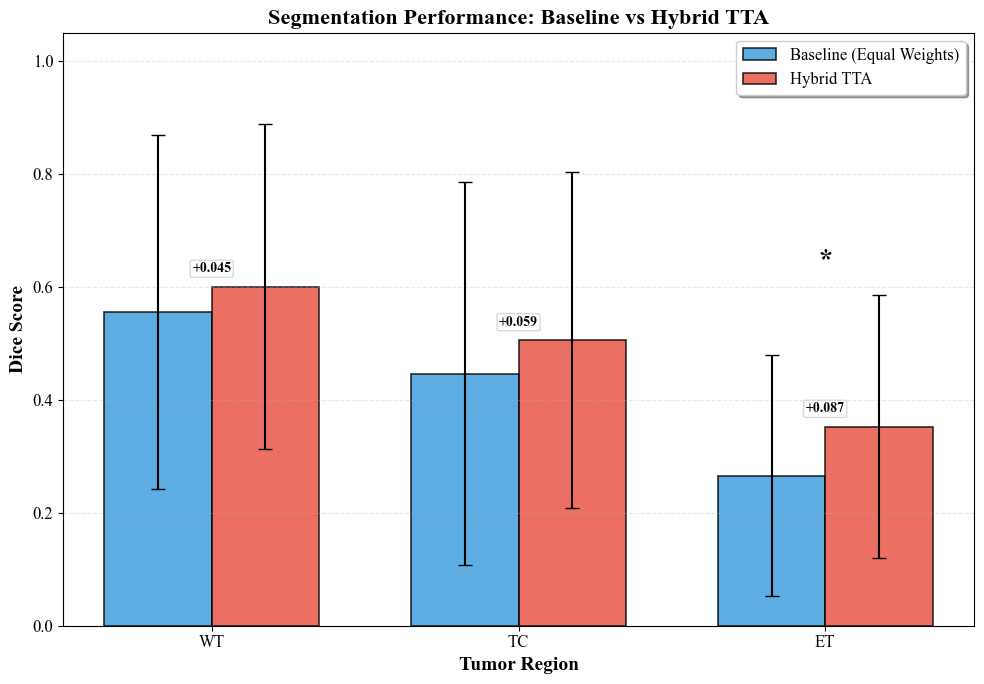

✓ Dice comparison plot saved!


In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 12

df = pd.read_csv('hybrid_tta_results.csv')

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

regions = ['WT', 'TC', 'ET']
x = np.arange(len(regions))
width = 0.35

baseline_means = [df[f'{r}_Baseline'].mean() for r in regions]
tta_means = [df[f'{r}_TTA'].mean() for r in regions]
baseline_stds = [df[f'{r}_Baseline'].std() for r in regions]
tta_stds = [df[f'{r}_TTA'].std() for r in regions]

bars1 = ax.bar(x - width/2, baseline_means, width, yerr=baseline_stds,
               label='Baseline (Equal Weights)', color='#3498db', alpha=0.8,
               capsize=5, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x + width/2, tta_means, width, yerr=tta_stds,
               label='Hybrid TTA', color='#e74c3c', alpha=0.8,
               capsize=5, edgecolor='black', linewidth=1.2)

# Add significance stars above error bars
p_values = [0.516, 0.240, 0.019]
for i, (p, r) in enumerate(zip(p_values, regions)):
    if p < 0.05:
        y_pos = max(tta_means[i] + tta_stds[i], baseline_means[i] + baseline_stds[i]) + 0.04
        ax.text(i, y_pos, '*', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax.set_ylabel('Dice Score', fontweight='bold', fontsize=14)
ax.set_xlabel('Tumor Region', fontweight='bold', fontsize=14)
ax.set_title('Segmentation Performance: Baseline vs Hybrid TTA', fontweight='bold', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(regions)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 1.05)

# Add improvement text above each bar group (no overlap with bars or error bars)
for i, r in enumerate(regions):
    improvement = tta_means[i] - baseline_means[i]
    y_pos = max(tta_means[i], baseline_means[i]) + 0.02
    ax.text(i, y_pos, f'{improvement:+.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='black',
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', edgecolor='lightgray', alpha=0.85))

plt.tight_layout()
plt.savefig('dice_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Dice comparison plot saved!")

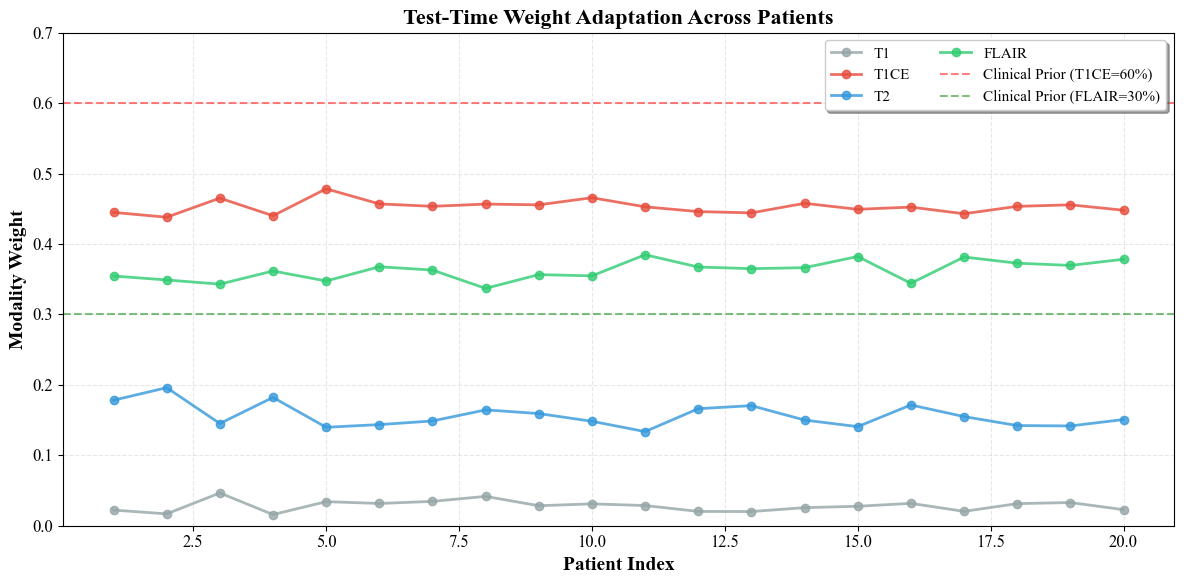

✓ Weight evolution plot saved!


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

patients = np.arange(1, len(df) + 1)
modalities = ['T1', 'T1CE', 'T2', 'FLAIR']
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']

for mod, color in zip(modalities, colors):
    weights = df[f'{mod}_Weight'].values
    ax.plot(patients, weights, marker='o', linewidth=2, markersize=6, 
            label=mod, color=color, alpha=0.8)

# Add clinical prior reference line for T1CE
ax.axhline(y=0.60, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Clinical Prior (T1CE=60%)')
ax.axhline(y=0.30, color='green', linestyle='--', alpha=0.5, linewidth=1.5, label='Clinical Prior (FLAIR=30%)')

ax.set_xlabel('Patient Index', fontweight='bold', fontsize=14)
ax.set_ylabel('Modality Weight', fontweight='bold', fontsize=14)
ax.set_title('Test-Time Weight Adaptation Across Patients', fontweight='bold', fontsize=16)
ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True, fontsize=11, ncol=2)
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim(0, 0.7)

plt.tight_layout()
plt.savefig('weight_evolution.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Weight evolution plot saved!")

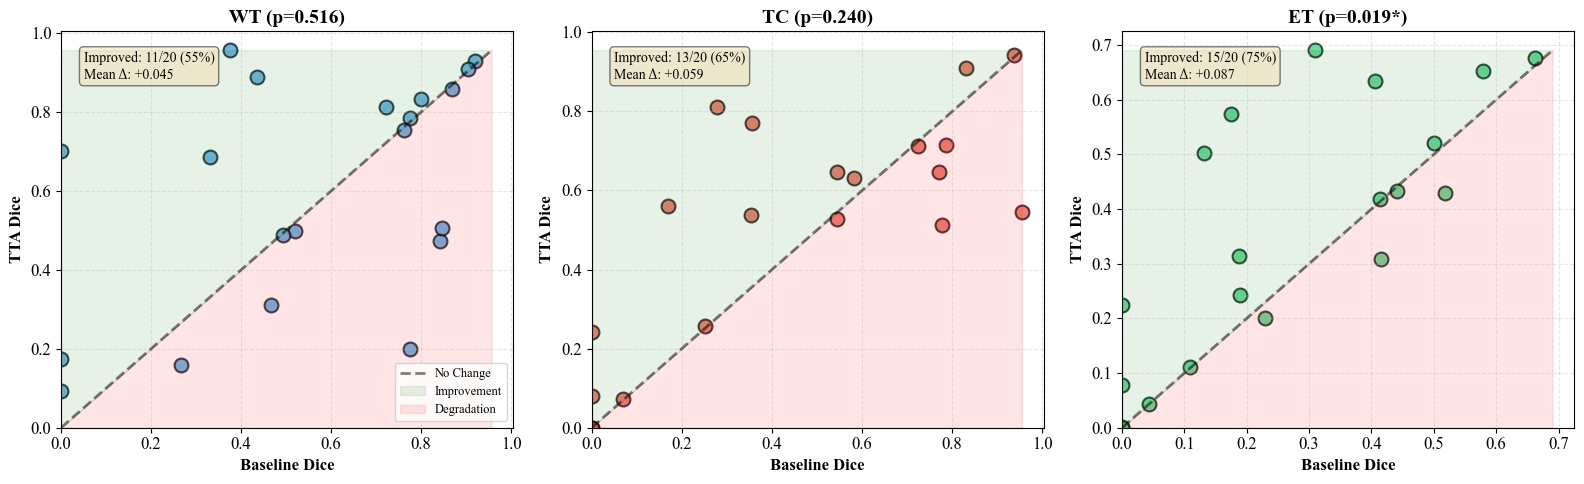

✓ Per-patient improvement scatter saved!


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

regions = ['WT', 'TC', 'ET']
colors = ['#3498db', '#e74c3c', '#2ecc71']
p_values = [0.516, 0.240, 0.019]

for i, (ax, region, color, p) in enumerate(zip(axes, regions, colors, p_values)):
    baseline = df[f'{region}_Baseline'].values
    tta = df[f'{region}_TTA'].values
    improvements = tta - baseline
    
    # Scatter plot
    ax.scatter(baseline, tta, s=100, alpha=0.7, color=color, edgecolors='black', linewidth=1.5)
    
    # Diagonal line (no improvement)
    max_val = max(baseline.max(), tta.max())
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.5, linewidth=2, label='No Change')
    
    # Color regions
    ax.fill_between([0, max_val], [0, max_val], max_val, alpha=0.1, color='green', label='Improvement')
    ax.fill_between([0, max_val], 0, [0, max_val], alpha=0.1, color='red', label='Degradation')
    
    ax.set_xlabel('Baseline Dice', fontweight='bold', fontsize=12)
    ax.set_ylabel('TTA Dice', fontweight='bold', fontsize=12)
    
    # Title with p-value
    sig = '*' if p < 0.05 else ''
    ax.set_title(f'{region} (p={p:.3f}{sig})', fontweight='bold', fontsize=14)
    
    ax.grid(alpha=0.3, linestyle='--')
    ax.set_xlim(0, max_val * 1.05)
    ax.set_ylim(0, max_val * 1.05)
    
    # Stats text
    positive = (improvements > 0).sum()
    mean_imp = improvements.mean()
    stats_text = f'Improved: {positive}/{len(df)} ({positive/len(df)*100:.0f}%)\nMean Δ: {mean_imp:+.3f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[0].legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('per_patient_improvements.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Per-patient improvement scatter saved!")

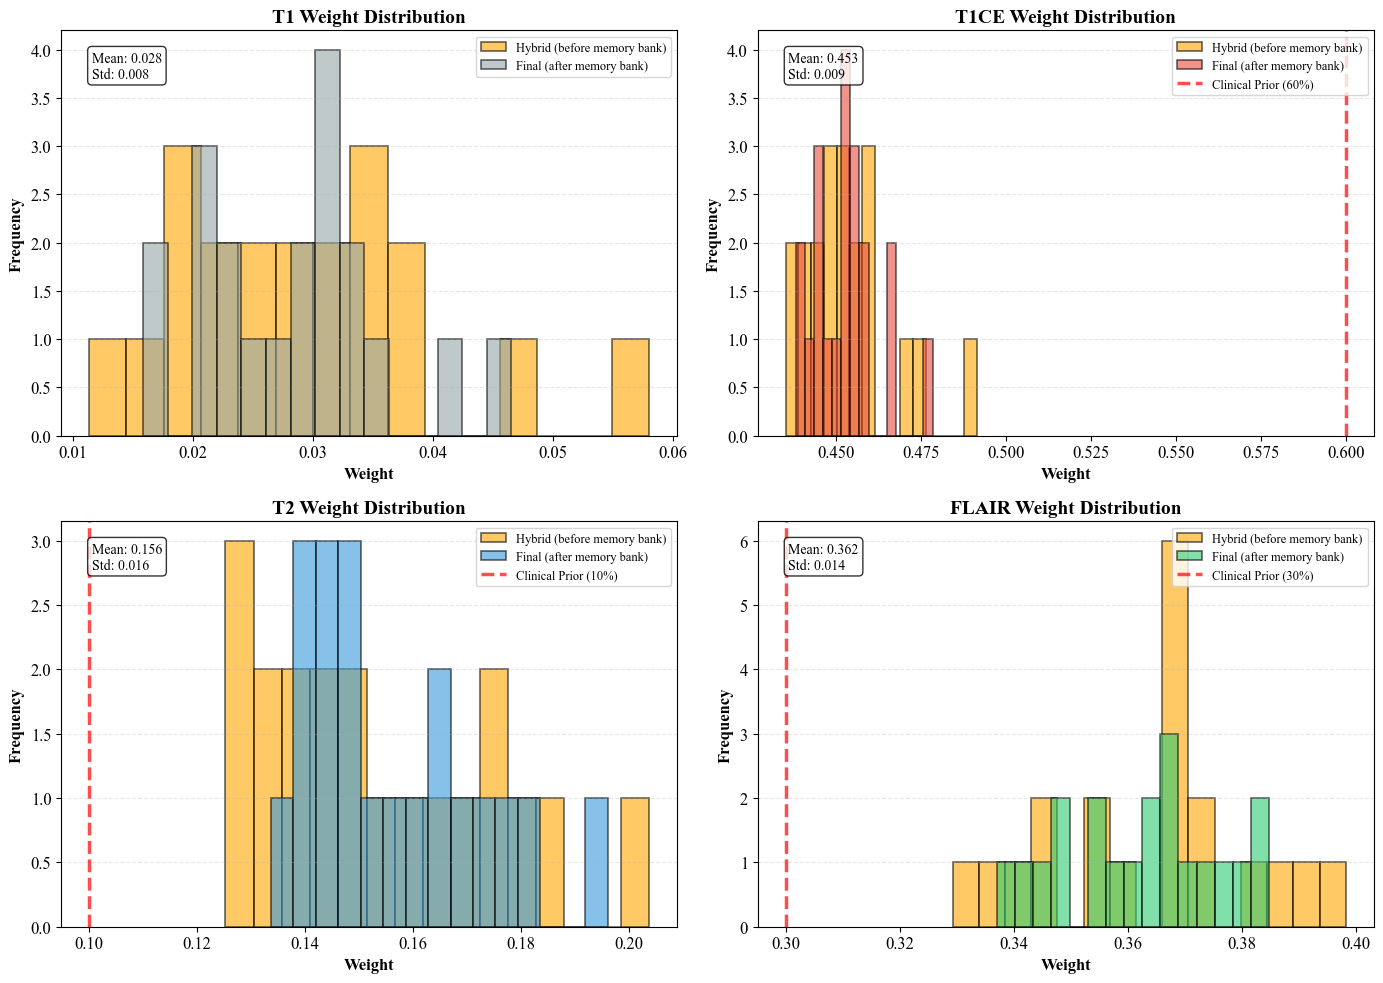

✓ Weight distribution plot saved!


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

modalities = ['T1', 'T1CE', 'T2', 'FLAIR']
colors = ['#95a5a6', '#e74c3c', '#3498db', '#2ecc71']
clinical_prior = [0.00, 0.60, 0.10, 0.30]

for i, (ax, mod, color, prior) in enumerate(zip(axes, modalities, colors, clinical_prior)):
    hybrid = df[f'Hybrid_{mod}_Weight'].values
    final = df[f'{mod}_Weight'].values
    
    # Histograms
    ax.hist(hybrid, bins=15, alpha=0.6, color='orange', edgecolor='black', 
            linewidth=1.2, label='Hybrid (before memory bank)')
    ax.hist(final, bins=15, alpha=0.6, color=color, edgecolor='black',
            linewidth=1.2, label='Final (after memory bank)')
    
    # Clinical prior reference
    if prior > 0:
        ax.axvline(prior, color='red', linestyle='--', linewidth=2.5, 
                   alpha=0.7, label=f'Clinical Prior ({prior:.0%})')
    
    ax.set_xlabel('Weight', fontweight='bold', fontsize=12)
    ax.set_ylabel('Frequency', fontweight='bold', fontsize=12)
    ax.set_title(f'{mod} Weight Distribution', fontweight='bold', fontsize=14)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Stats text
    stats_text = f'Mean: {final.mean():.3f}\nStd: {final.std():.3f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('weight_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Weight distribution plot saved!")

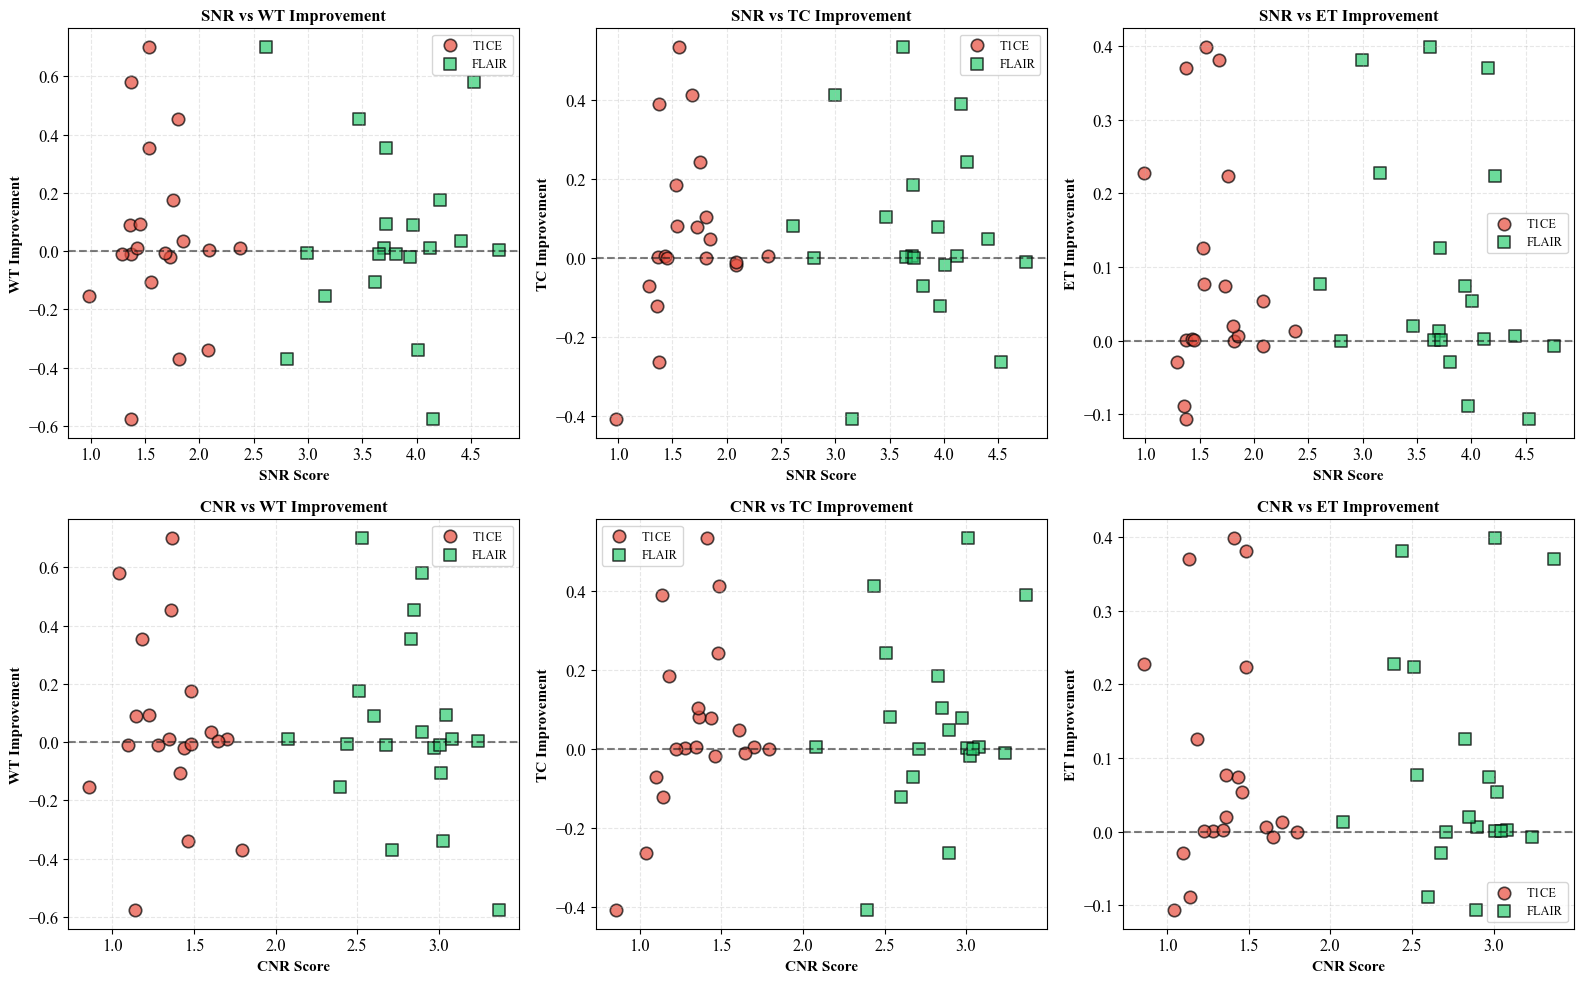

✓ SNR/CNR correlation plot saved!


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

regions = ['WT', 'TC', 'ET']
modalities_to_plot = ['T1CE', 'FLAIR']

for row, metric in enumerate(['SNR', 'CNR']):
    for col, region in enumerate(regions):
        ax = axes[row, col]
        
        improvements = df[f'{region}_TTA'] - df[f'{region}_Baseline']
        
        # Plot both T1CE and FLAIR
        for mod, color, marker in [('T1CE', '#e74c3c', 'o'), ('FLAIR', '#2ecc71', 's')]:
            metric_vals = df[f'{mod}_{metric}'].values
            ax.scatter(metric_vals, improvements, s=80, alpha=0.7, 
                      color=color, marker=marker, edgecolors='black', 
                      linewidth=1.2, label=mod)
        
        # Zero line
        ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
        
        ax.set_xlabel(f'{metric} Score', fontweight='bold', fontsize=11)
        ax.set_ylabel(f'{region} Improvement', fontweight='bold', fontsize=11)
        ax.set_title(f'{metric} vs {region} Improvement', fontweight='bold', fontsize=12)
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.savefig('snr_cnr_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ SNR/CNR correlation plot saved!")